# Fully non-collinear Nambu basis

Every transport routine above works on a Bogoliubov-de Gennes (Nambu) Hamiltonian without
assuming any particular spin structure: leads may combine Rashba spin-orbit coupling, an exchange
(Zeeman) field pointing along an *arbitrary*, not-necessarily-shared direction, and s-wave
pairing all at once -- a genuinely non-collinear 4-component (spin $\times$ electron/hole) Nambu
spinor with no conserved spin quantization axis. This is checked directly below: a Hamiltonian
has a conserved spin axis $\hat n$ only if $[H,\vec S\cdot\hat n]=0$ for that axis, so a
non-collinear Hamiltonian must fail to commute with $S_x$, $S_y$ *and* $S_z$ simultaneously --
unlike a purely collinear (single-axis Zeeman, no Rashba) reference case, where the shared axis
commutes exactly.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

Collinear reference, commutator norms: {'sx': np.float64(0.8), 'sy': np.float64(0.8), 'sz': np.float64(0.0)}
Non-collinear lead 2, commutator norms: {'sx': np.float64(1.0), 'sy': np.float64(0.20000000000000018), 'sz': np.float64(1.019803902718557)}


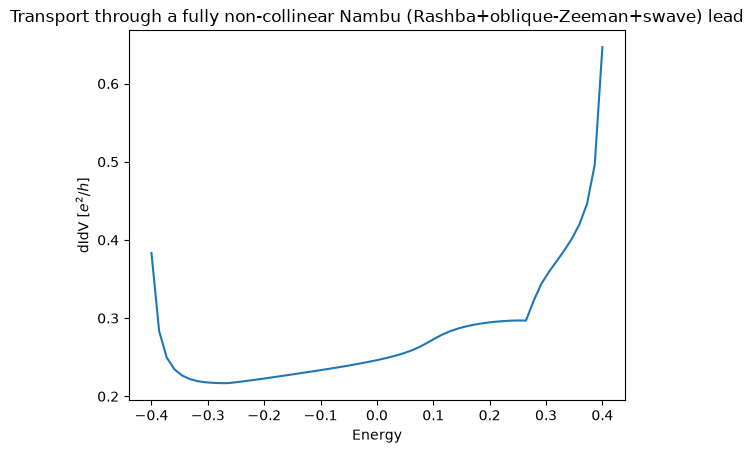

In [2]:
def commutator_norms(h):
    ops = {name: h.get_operator(name).get_matrix() for name in ["sx","sy","sz"]}
    return {name: np.max(np.abs(h.intra@op-op@h.intra)) for name,op in ops.items()}

g = geometry.chain()
h = g.get_hamiltonian(has_spin=True)

# collinear reference: Zeeman along a single shared axis (z), no Rashba --
# spin is a good quantum number, [H,Sz]=0
h_collinear = h.copy()
h_collinear.add_zeeman([0.,0.,0.4])
h_collinear.add_swave(0.1)
print("Collinear reference, commutator norms:",commutator_norms(h_collinear))

# fully non-collinear: Rashba SOC + an oblique-axis Zeeman field, no shared spin axis
h1 = h.copy() # normal lead, itself spin-textured
h1.add_rashba(0.6)
h1.add_zeeman([0.3,0.2,0.4])

h2 = h.copy() # topological/non-collinear superconducting lead
h2.add_rashba(0.6)
h2.add_zeeman([-0.1,0.5,0.1]) # a DIFFERENT, non-parallel oblique axis
h2.add_onsite(2.0)
h2.add_swave(0.1)
print("Non-collinear lead 2, commutator norms:",commutator_norms(h2))

ht = heterostructures.build(h1,h2)
ht.scale_lc = 0.3
ht.delta = 1e-6
es = np.linspace(-.4,.4,60)
Gs = [ht.didv(energy=e) for e in es]

plt.plot(es,Gs)
plt.xlabel("Energy") ; plt.ylabel("dIdV [$e^2/h$]")
plt.title("Transport through a fully non-collinear Nambu (Rashba+oblique-Zeeman+swave) lead")
plt.show()